# N2 · 世界模型预测质量: 多步误差累积

> 配套 13.5-L1/L4 · 想象 rollout 是自回归的 —— 每步小误差会喂进下一步, 复利式放大。
> 量化「想象 vs 真实」的误差随步数怎么增长。这是世界模型 (和长程视频/自回归预测) 的核心难题。

In [1]:
import sys
from pathlib import Path
SRC = Path.cwd().parent / "src"
sys.path.insert(0, str(SRC))
import numpy as np, torch
import world_model as wm
print('就绪')

就绪


## 1. 训世界模型, 测多步误差增长曲线

In [2]:
torch.manual_seed(0)
data = wm.make_transitions(n=4000, seed=0)
model = wm.build_world_model()
wm.train_world_model(model, data, epochs=400)
errs = wm.multistep_error(model, n_traj=80, horizon=25)
for h in [1,5,10,15,20,25]:
    print(f'  {h:2d} 步想象: 平均误差 {errs[h]:.3f}')
print('→ 1 步很准, 步数越多误差越大 (复利累积)。')

   1 步想象: 平均误差 0.015
   5 步想象: 平均误差 0.038
  10 步想象: 平均误差 0.056
  15 步想象: 平均误差 0.069
  20 步想象: 平均误差 0.078
  25 步想象: 平均误差 0.086
→ 1 步很准, 步数越多误差越大 (复利累积)。


## 2. 误差累积曲线 (短期可信, 长期发散)

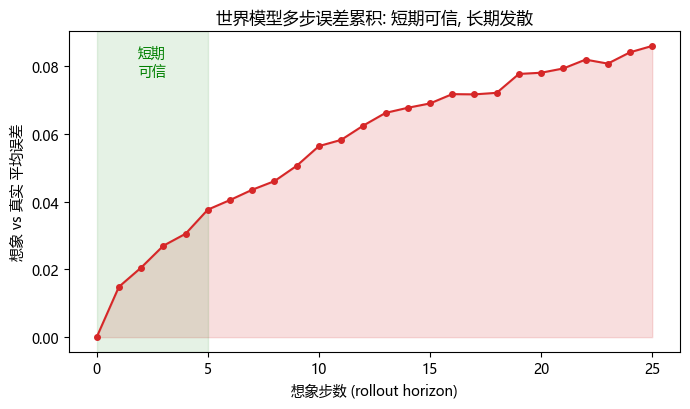

→ 这是 model-based 规划用「短视野 + 重规划 (MPC) + 真观测纠偏」对抗的根本难题 (L1/L4)。


In [3]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
fig, ax = plt.subplots(figsize=(7,4.2))
H = len(errs)-1
ax.plot(range(H+1), errs, '-o', ms=4, color='C3')
ax.fill_between(range(H+1), 0, errs, alpha=0.15, color='C3')
ax.set_xlabel('想象步数 (rollout horizon)'); ax.set_ylabel('想象 vs 真实 平均误差')
ax.set_title('世界模型多步误差累积: 短期可信, 长期发散')
ax.axvspan(0,5,alpha=0.1,color='green'); ax.text(2.5, errs.max()*0.9, '短期\n可信', ha='center', color='green')
plt.tight_layout(); plt.show()
print('→ 这是 model-based 规划用「短视野 + 重规划 (MPC) + 真观测纠偏」对抗的根本难题 (L1/L4)。')

## 3. 1 步预测其实很准 (问题在累积, 不在单步)

In [4]:
# 单步预测误差 (不累积): 直接在真转移上测
rng = np.random.default_rng(7)
s = rng.uniform(-1,1,size=(500,2)).astype(np.float32)
a = rng.integers(0, wm.N_ACTIONS, size=500)
true_next = np.stack([wm.true_step(s[i], int(a[i]), rng) for i in range(500)])
import torch
with torch.no_grad():
    onehot = torch.nn.functional.one_hot(torch.tensor(a), wm.N_ACTIONS).float()
    pred_delta = model(torch.tensor(s), onehot).numpy()
pred_next = np.clip(s + pred_delta, -1, 1)
single = np.linalg.norm(pred_next - true_next, axis=-1).mean()
print(f'单步预测误差: {single:.4f} (很小)')
print(f'25 步累积误差: {errs[25]:.4f} (是单步的 {errs[25]/single:.0f}×)')
print('→ 世界模型单步很准; 难点是自回归把小误差滚成大偏差。这正是长程一致 (M13.4-L3) 的同一根难题。')

单步预测误差: 0.0148 (很小)
25 步累积误差: 0.0859 (是单步的 6×)
→ 世界模型单步很准; 难点是自回归把小误差滚成大偏差。这正是长程一致 (M13.4-L3) 的同一根难题。


## 4. 反思 (13.5 收口)

你量化了世界模型的核心难题: **多步误差累积**。带走:
- **单步准 ≠ 多步准**: 自回归想象把每步小误差复利放大, 长程发散。
- 这和 M13.4-L3 的长程视频不一致是**同一根难题** (自回归预测的通病)。
- 对抗手段: 短规划视野、MPC 重规划、周期性用真观测纠偏 (接 RL/M11)。
- 评测世界模型 = 看误差增长曲线 (但「懂物理 vs 拟合」更深的评测仍是 open, L4)。

> **M13.5 收口**: 世界模型 = 动作条件的生成式预测; 能想象 rollout (规划地基); 误差累积是主敌; 它是生成(M13)与具身(M11)的共享内核。
> **交棒 M13.6「diffusion-language-models」**: 生成式媒体绕一圈回你本行 —— 文本也能扩散 (masked diffusion LM, 并行生成)。下一专题 `diffusion-language-models`。